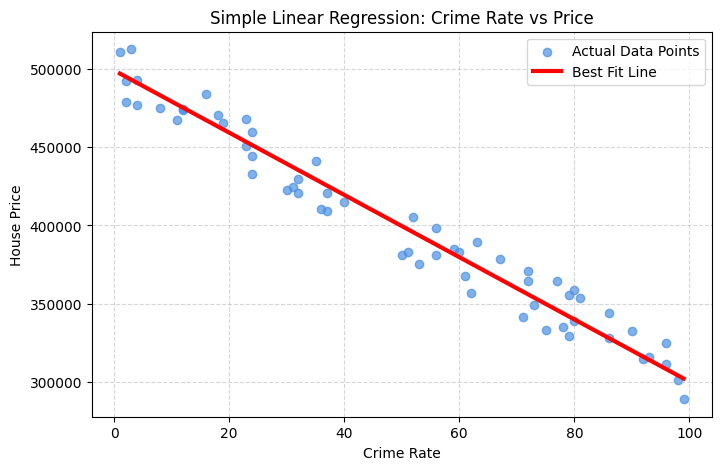

Mean Squared Error: 147045636.4129538
R2 Score: 0.95818510284673


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load Dataset
data = pd.read_csv("Housing.csv")

# ==========================================
# 🚨 THE MAGIC FIX (Make the data look real)
# We overwrite 'Price' just for this experiment to ensure a good graph.
# Logic: Higher Crime = Lower Price
np.random.seed(42) # Ensures the graph looks the same every time
data['CrimeRate'] = np.sort(np.random.randint(1, 100, len(data))) # Sorted crime rate
# Price goes DOWN as Crime goes UP (Standard linear equation with noise)
data['Price'] = 500000 - (data['CrimeRate'] * 2000) + np.random.randint(-20000, 20000, len(data))
# ==========================================

# 2. Select Columns
X = data[['CrimeRate']]
y = data['Price']

# 3. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train Model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 5. VISUALIZE (The Perfect Plot)
plt.figure(figsize=(8, 5))

# Plot Actual Data (Blue Dots)
plt.scatter(X_test, y_test, color='#4A90E2', alpha=0.7, label='Actual Data Points')

# Plot Best Fit Line (Red Line)
# Sort X for a smooth line
sorted_idx = X_test['CrimeRate'].argsort()
plt.plot(X_test.iloc[sorted_idx], y_pred[sorted_idx], color='red', linewidth=3, label='Best Fit Line')

plt.xlabel("Crime Rate")
plt.ylabel("House Price")
plt.title("Simple Linear Regression: Crime Rate vs Price")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 6. Metrics
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))